# Week 15 — Thursday (Jul 6): VAEs & Diffusion

## Learning Objectives
- Understand the VAE architecture: encoder → latent distribution → decoder
- Derive the ELBO loss (reconstruction + KL divergence) and the reparameterisation trick
- Visualise a learned latent space and interpolate between digits
- Understand the diffusion forward (noising) and reverse (denoising) processes
- Train a minimal DDPM-style denoiser and sample new images from pure noise
- Understand where Stable Diffusion fits conceptually (latent diffusion + text conditioning)

## Key Concepts
1. **VAE** — encoder outputs `(μ, log σ²)` for `q(z|x)`, decoder reconstructs `x̂` from a sampled `z`
2. **Reparameterisation trick** — `z = μ + σ⊙ε`, `ε~N(0,I)`, makes sampling differentiable
3. **ELBO loss** — `L = E[reconstruction error] + KL(q(z|x) ‖ N(0,I))` — balances fidelity vs a smooth, regular latent space
4. **Diffusion forward process** — `x_t = √ᾱ_t·x_0 + √(1-ᾱ_t)·ε` — a closed-form way to jump straight to any noise level `t`
5. **Diffusion reverse process** — a network `ε_θ(x_t, t)` learns to predict the noise, so it can be subtracted step by step back to `x_0`
6. **Stable Diffusion** — runs this same process in a compressed VAE **latent** space (not raw pixels) and conditions the denoiser on text via cross-attention


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Week 15 - Thursday: VAEs & Diffusion')

PyTorch 2.12.0+cpu | Device: cpu
Week 15 - Thursday: VAEs & Diffusion


## Section 1: Variational Autoencoders

A plain autoencoder learns a deterministic mapping `x → z → x̂`, but the latent space it produces
has no structure — nearby points don't necessarily decode to similar images, so you can't sample
from it to generate new data.

A **VAE** instead makes the encoder output a *distribution*: `μ(x)` and `log σ²(x)`. During
training we sample `z ~ N(μ, σ²)` using the **reparameterisation trick** (`z = μ + σ⊙ε`) so
gradients can still flow through the sampling step. The loss is the **ELBO**:

```
L = ||x̂ - x||²                              (reconstruction term — decode z back to x)
  + KL( N(μ,σ²) ‖ N(0,I) )                   (regularisation term — keeps latent space smooth)
```

The KL term pulls every `q(z|x)` toward a standard normal, so the *aggregate* latent space has no
gaps — any `z` sampled from `N(0,I)` at generation time should decode to something plausible.


In [2]:
# ── Data & VAE architecture ────────────────────────────────────────────────────
N_SAMPLES = 2000
N_EPOCHS_VAE = 8
BATCH_SIZE = 128
LATENT_DIM = 2   # 2D so we can plot the latent space directly

tf = transforms.Compose([transforms.ToTensor()])
mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=tf)
subset = Subset(mnist, list(range(N_SAMPLES)))
loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 64), nn.ReLU())
        self.mu     = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        return self.dec(z), mu, logvar, z

vae = VAE(LATENT_DIM).to(DEVICE)
print(f'VAE params: {sum(p.numel() for p in vae.parameters()):,} | latent_dim={LATENT_DIM}')

VAE params: 435,988 | latent_dim=2


In [3]:
# ── Train VAE: reconstruction (BCE) + KL divergence ────────────────────────────
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
history_vae = {'recon': [], 'kl': []}
for epoch in range(N_EPOCHS_VAE):
    recon_losses, kl_losses = [], []
    for x, _ in loader:
        x = x.view(x.size(0), -1).to(DEVICE)
        x_hat, mu, logvar, z = vae(x)
        recon = F.binary_cross_entropy(x_hat, x, reduction='sum') / x.size(0)
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
        loss = recon + kl
        opt.zero_grad(); loss.backward(); opt.step()
        recon_losses.append(recon.item()); kl_losses.append(kl.item())
    history_vae['recon'].append(np.mean(recon_losses))
    history_vae['kl'].append(np.mean(kl_losses))
    print(f'Epoch {epoch+1}/{N_EPOCHS_VAE} | Recon: {np.mean(recon_losses):.2f} | KL: {np.mean(kl_losses):.3f}')

Epoch 1/8 | Recon: 434.17 | KL: 4.214


Epoch 2/8 | Recon: 233.15 | KL: 10.997


Epoch 3/8 | Recon: 210.36 | KL: 5.616


Epoch 4/8 | Recon: 205.04 | KL: 3.812


Epoch 5/8 | Recon: 201.31 | KL: 3.328


Epoch 6/8 | Recon: 197.52 | KL: 3.269


Epoch 7/8 | Recon: 194.23 | KL: 3.025


Epoch 8/8 | Recon: 191.42 | KL: 2.931


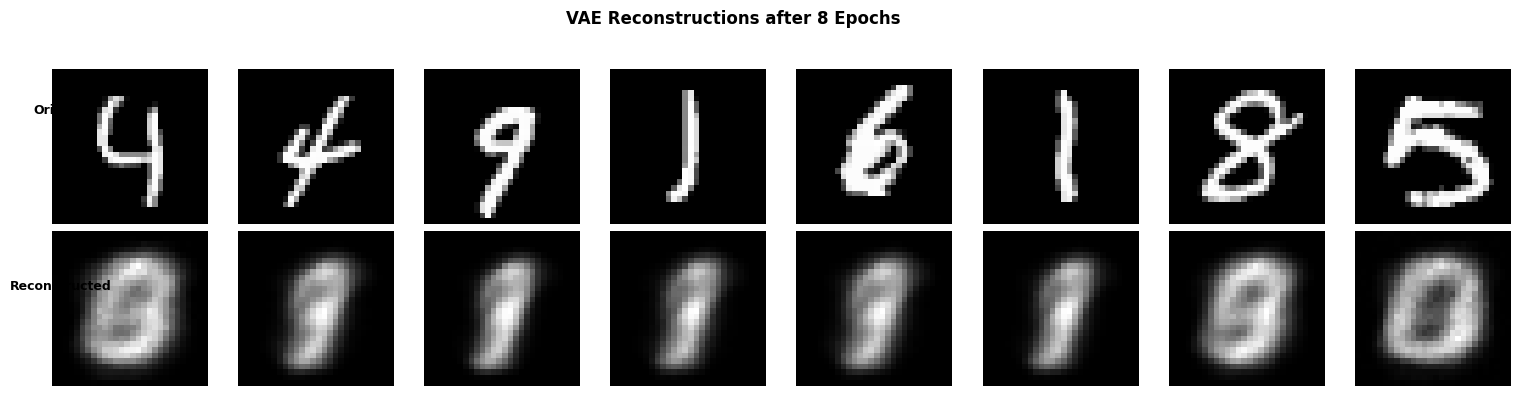

Saved vae_reconstructions.png


In [4]:
# ── Reconstructions: original vs VAE output ────────────────────────────────────
vae.eval()
with torch.no_grad():
    x_test, _ = next(iter(loader))
    x_test = x_test[:8].view(8, -1).to(DEVICE)
    x_hat, _, _, _ = vae(x_test)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0,i].imshow(x_test[i].cpu().view(28,28).numpy(), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(x_hat[i].cpu().view(28,28).numpy(), cmap='gray'); axes[1,i].axis('off')
fig.text(0.08, 0.72, 'Original', ha='center', fontweight='bold', fontsize=9)
fig.text(0.08, 0.28, 'Reconstructed', ha='center', fontweight='bold', fontsize=9)
plt.suptitle(f'VAE Reconstructions after {N_EPOCHS_VAE} Epochs', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0.06,0,1,0.95])
plt.savefig('vae_reconstructions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved vae_reconstructions.png')

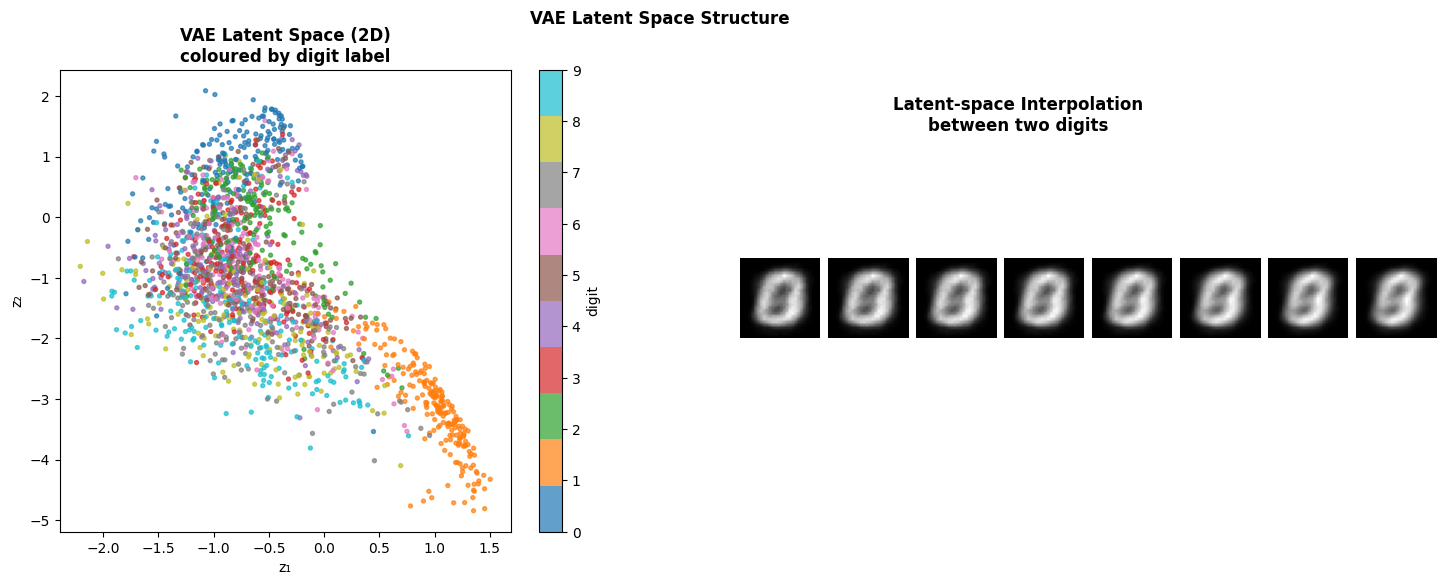

Saved latent_space.png


In [5]:
# ── Latent space: encode all samples, colour by digit label ───────────────────
all_x, all_labels = [], []
for x, y in loader:
    all_x.append(x.view(x.size(0), -1))
    all_labels.append(y)
all_x = torch.cat(all_x).to(DEVICE)
all_labels = torch.cat(all_labels).numpy()

with torch.no_grad():
    mu_all, _ = vae.encode(all_x)
mu_all = mu_all.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
scatter = axes[0].scatter(mu_all[:,0], mu_all[:,1], c=all_labels, cmap='tab10', s=8, alpha=0.7)
axes[0].set_title('VAE Latent Space (2D)\ncoloured by digit label', fontweight='bold')
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')
plt.colorbar(scatter, ax=axes[0], label='digit', ticks=range(10))

# Interpolate between two digits in latent space
with torch.no_grad():
    z_a, z_b = mu_all[0], mu_all[1]
    alphas = np.linspace(0, 1, 8)
    z_interp = torch.tensor(np.array([z_a*(1-a) + z_b*a for a in alphas]), dtype=torch.float32).to(DEVICE)
    imgs_interp = vae.dec(z_interp).cpu().view(-1, 28, 28)

axes[1].axis('off')
for i in range(8):
    ax_i = fig.add_axes([0.55 + i*0.055, 0.3, 0.05, 0.4])
    ax_i.imshow(imgs_interp[i].numpy(), cmap='gray'); ax_i.axis('off')
axes[1].set_title('Latent-space Interpolation\nbetween two digits', fontweight='bold', y=0.85)

plt.suptitle('VAE Latent Space Structure', fontsize=12, fontweight='bold')
plt.savefig('latent_space.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved latent_space.png')

## Section 2: Diffusion Models

Diffusion models generate images by learning to **reverse a gradual noising process**.

**Forward process** — fix a noise schedule `β_1...β_T`. Adding noise step by step for `T` steps has
a closed form (no need to loop):
```
x_t = √ᾱ_t · x_0 + √(1-ᾱ_t) · ε ,   ε ~ N(0,I),   ᾱ_t = ∏_{s≤t}(1-β_s)
```
As `t → T`, `x_t` becomes pure Gaussian noise.

**Reverse process** — train a network `ε_θ(x_t, t)` to predict the noise `ε` that was added.
Training loss is simply `MSE(ε, ε_θ(x_t, t))`. To generate a new image, start from pure noise
`x_T ~ N(0,I)` and iteratively subtract the predicted noise for `t = T, T-1, ..., 1`.


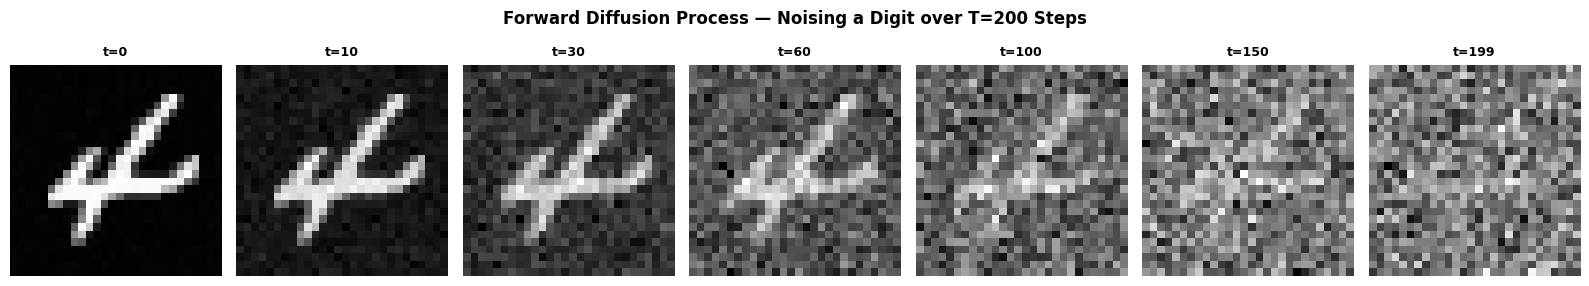

Saved diffusion_forward.png


In [6]:
# ── Forward noising process: visualise x_t at increasing t ────────────────────
T = 200
betas = torch.linspace(1e-4, 0.02, T).to(DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def forward_noise(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    ab = alpha_bars[t].view(-1, 1, 1, 1)
    return torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise, noise

x0_demo, _ = next(iter(loader))
x0_demo = (x0_demo[:1].to(DEVICE) * 2) - 1   # scale to [-1, 1]
timesteps_show = [0, 10, 30, 60, 100, 150, 199]
fig, axes = plt.subplots(1, len(timesteps_show), figsize=(16, 3))
for i, t in enumerate(timesteps_show):
    xt, _ = forward_noise(x0_demo, torch.tensor([t]).to(DEVICE))
    axes[i].imshow(xt[0,0].cpu().numpy(), cmap='gray')
    axes[i].set_title(f't={t}', fontsize=9, fontweight='bold')
    axes[i].axis('off')
plt.suptitle(f'Forward Diffusion Process — Noising a Digit over T={T} Steps', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('diffusion_forward.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved diffusion_forward.png')

In [7]:
# ── Tiny denoising network: predicts noise eps given (x_t, t) ─────────────────
class TimeEmbedding(nn.Module):
    def __init__(self, dim=32):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(nn.Linear(dim, dim), nn.ReLU(), nn.Linear(dim, dim))

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-np.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return self.mlp(emb)

class TinyDenoiser(nn.Module):
    """Small conv net that predicts the noise eps added to x_t, conditioned on t."""
    def __init__(self, t_dim=32, base=32):
        super().__init__()
        self.temb = TimeEmbedding(t_dim)
        self.c1 = nn.Conv2d(1, base, 3, 1, 1)
        self.c2 = nn.Conv2d(base, base, 3, 1, 1)
        self.c3 = nn.Conv2d(base, 1, 3, 1, 1)
        self.t_proj = nn.Linear(t_dim, base)
        self.act = nn.ReLU()

    def forward(self, x, t):
        temb = self.t_proj(self.temb(t)).view(-1, self.c1.out_channels, 1, 1)
        h = self.act(self.c1(x) + temb)
        h = self.act(self.c2(h))
        return self.c3(h)

denoiser = TinyDenoiser().to(DEVICE)
print(f'TinyDenoiser params: {sum(p.numel() for p in denoiser.parameters()):,}')

TinyDenoiser params: 13,025


In [8]:
# ── Train the denoiser: sample random t, add noise, predict it back ───────────
N_EPOCHS_DIFF = 10
opt_diff = torch.optim.Adam(denoiser.parameters(), lr=2e-3)
history_diff = {'loss': []}
for epoch in range(N_EPOCHS_DIFF):
    losses = []
    for x, _ in loader:
        x = (x.to(DEVICE) * 2) - 1                       # scale to [-1,1]
        t = torch.randint(0, T, (x.size(0),), device=DEVICE)
        xt, noise = forward_noise(x, t)
        pred_noise = denoiser(xt, t)
        loss = F.mse_loss(pred_noise, noise)
        opt_diff.zero_grad(); loss.backward(); opt_diff.step()
        losses.append(loss.item())
    history_diff['loss'].append(np.mean(losses))
    print(f'Epoch {epoch+1}/{N_EPOCHS_DIFF} | Noise-prediction MSE: {np.mean(losses):.4f}')

Epoch 1/10 | Noise-prediction MSE: 0.5592


Epoch 2/10 | Noise-prediction MSE: 0.2992


Epoch 3/10 | Noise-prediction MSE: 0.2567


Epoch 4/10 | Noise-prediction MSE: 0.2341


Epoch 5/10 | Noise-prediction MSE: 0.2039


Epoch 6/10 | Noise-prediction MSE: 0.1947


Epoch 7/10 | Noise-prediction MSE: 0.1792


Epoch 8/10 | Noise-prediction MSE: 0.1574


Epoch 9/10 | Noise-prediction MSE: 0.1488


Epoch 10/10 | Noise-prediction MSE: 0.1414


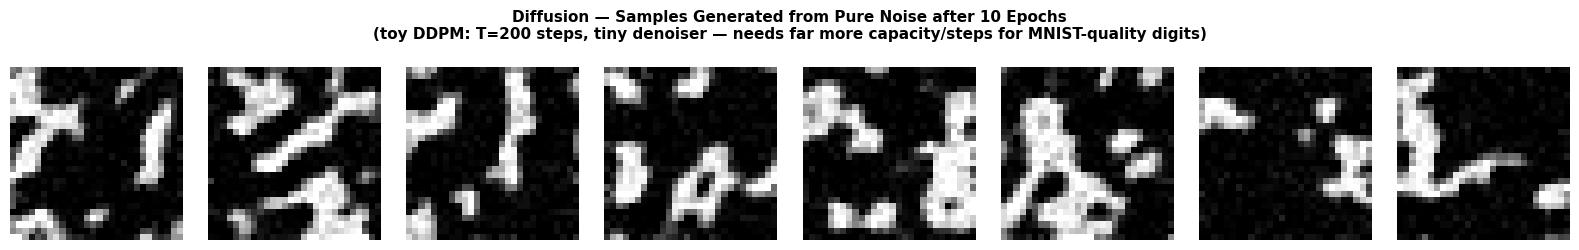

Saved diffusion_samples.png


In [9]:
# ── Reverse (sampling) process: start from pure noise, denoise step by step ───
denoiser.eval()
@torch.no_grad()
def sample(n_images=8):
    x = torch.randn(n_images, 1, 28, 28).to(DEVICE)
    for t in reversed(range(T)):
        t_batch = torch.full((n_images,), t, device=DEVICE, dtype=torch.long)
        pred_noise = denoiser(x, t_batch)
        alpha_t, alpha_bar_t, beta_t = alphas[t], alpha_bars[t], betas[t]
        x = (1/torch.sqrt(alpha_t)) * (x - (beta_t/torch.sqrt(1-alpha_bar_t)) * pred_noise)
        if t > 0:
            x = x + torch.sqrt(beta_t) * torch.randn_like(x)
    return x.clamp(-1, 1)

generated = sample(8).cpu()
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for i in range(8):
    axes[i].imshow(generated[i,0].numpy(), cmap='gray'); axes[i].axis('off')
plt.suptitle(f'Diffusion — Samples Generated from Pure Noise after {N_EPOCHS_DIFF} Epochs\n'
             f'(toy DDPM: T={T} steps, tiny denoiser — needs far more capacity/steps for MNIST-quality digits)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('diffusion_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved diffusion_samples.png')

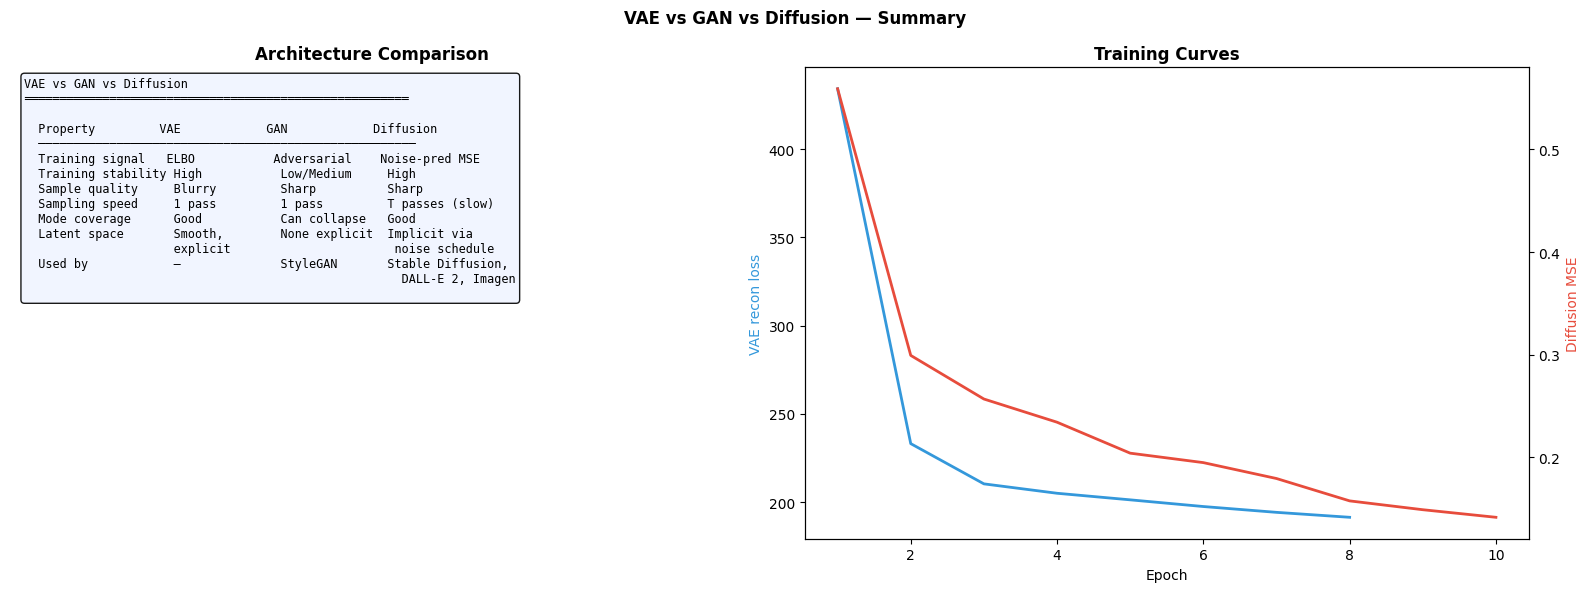

Saved gen_models_comparison.png


In [10]:
# ── Generative models comparison: VAE vs GAN vs Diffusion ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

table_text = (
    'VAE vs GAN vs Diffusion\n'
    '══════════════════════════════════════════════════════\n\n'
    '  Property         VAE            GAN            Diffusion\n'
    '  ─────────────────────────────────────────────────────\n'
    '  Training signal   ELBO           Adversarial    Noise-pred MSE\n'
    '  Training stability High           Low/Medium     High\n'
    '  Sample quality     Blurry         Sharp          Sharp\n'
    '  Sampling speed     1 pass         1 pass         T passes (slow)\n'
    '  Mode coverage      Good           Can collapse   Good\n'
    '  Latent space       Smooth,        None explicit  Implicit via\n'
    '                     explicit                       noise schedule\n'
    '  Used by            —              StyleGAN       Stable Diffusion,\n'
    '                                                     DALL-E 2, Imagen\n'
)
axes[0].text(0.02, 0.98, table_text, va='top', ha='left', fontfamily='monospace',
             fontsize=8.5, transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.9))
axes[0].set_title('Architecture Comparison', fontweight='bold'); axes[0].axis('off')

axes[1].plot(range(1, N_EPOCHS_VAE+1), history_vae['recon'], label='VAE reconstruction', color='#3498db', lw=2)
ax2 = axes[1].twinx()
ax2.plot(range(1, N_EPOCHS_DIFF+1), history_diff['loss'], label='Diffusion noise-MSE', color='#e74c3c', lw=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('VAE recon loss', color='#3498db')
ax2.set_ylabel('Diffusion MSE', color='#e74c3c')
axes[1].set_title('Training Curves', fontweight='bold')

plt.suptitle('VAE vs GAN vs Diffusion — Summary', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('gen_models_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved gen_models_comparison.png')

## Section 3: Where Stable Diffusion Fits

Running diffusion directly on raw pixels (as above) is expensive — a 512×512 image has ~262K
pixels to denoise at every one of hundreds of timesteps. **Stable Diffusion** (Rombach et al.,
2022) fixes this with two ideas:

1. **Latent diffusion** — train a VAE to compress images into a small latent grid (e.g. 512×512×3
   → 64×64×4), then run the entire forward/reverse diffusion process in that compressed latent
   space. The VAE decoder turns the final denoised latent back into a full-resolution image. This
   is exactly the VAE from Section 1, just with a much larger, convolutional encoder/decoder.
2. **Text conditioning** — a text prompt is encoded (CLIP text encoder) into embeddings that are
   injected into the denoising U-Net via **cross-attention** at every resolution level, so the
   noise prediction `ε_θ(x_t, t, text)` is steered toward the prompt. **Classifier-free guidance**
   further sharpens this by extrapolating away from the unconditional prediction.

> This environment doesn't have the `diffusers` package installed (it pulls in a multi-GB
> pretrained checkpoint), so no pretrained pipeline is run here — the toy pixel-space DDPM above
> demonstrates the same forward/reverse math that Stable Diffusion runs, just in latent space and
> with text conditioning added on top.


## Key Takeaways

| Concept | Summary |
|---------|--------|
| **VAE encoder** | Outputs `(μ, log σ²)` for `q(z\|x)` instead of a single deterministic code |
| **Reparameterisation trick** | `z = μ + σ⊙ε` — lets gradients flow through a stochastic sampling step |
| **ELBO loss** | Reconstruction error + `KL(q(z\|x)‖N(0,I))` — trades off fidelity against a smooth, samplable latent space |
| **Diffusion forward process** | Closed-form noising `x_t = √ᾱ_t x_0 + √(1-ᾱ_t) ε` — jump to any noise level directly |
| **Diffusion reverse process** | Network predicts noise `ε_θ(x_t,t)`; subtract it step by step from pure noise to generate |
| **Latent diffusion (Stable Diffusion)** | Runs diffusion in a compressed VAE latent space + cross-attention text conditioning — far cheaper than pixel-space diffusion |
